# Tolerância a Falhas Solar-Aware no Edge Computing com ILP (PuLP)

Este notebook implementa um experimento **coerente com a formulação do PDF** para o problema de tolerância a falhas **Solar-Aware** em **Edge Computing**, com base na ideia de **"Partição Energética"** e no uso de **PuLP + CBC** para obter uma linha de base *offline* do **Limite de Resiliência**.

## O que o notebook faz
1. Gera **dados sintéticos** para `N = 5` nós e `T = 24` horas.
2. Formula e resolve um **ILP** com:
   - ativação de nós,
   - migração proativa,
   - atualização de bateria,
   - uso de energia marrom,
   - restrição de **K-Resiliência**.
3. Salva os resultados em **pastas organizadas**.
4. Gera e salva **3 gráficos** em português.
5. Empacota tudo em um `.zip` para facilitar o download no Colab.

## Observação de coerência com o artigo
No texto do artigo, a função objetivo inclui o termo `E_brown * x`, o que introduz bilinearidade. Para manter a coerência conceitual **sem quebrar a linearidade do ILP**, este notebook usa a forma linear:

\[
\min \sum_{t \in T} \sum_{i \in N} \left( \alpha \cdot CFR_i \cdot E^{marrom}_{i,t} + \beta \cdot Custo^{mig}_i \cdot m_{i,t} \right)
\]

e garante, por restrições, que a energia marrom só apareça quando for necessária para sustentar atividade/operação do nó. Assim, preserva-se a intenção do PDF: **minimizar carbono + overhead de migração**, mantendo o problema solucionável via **PuLP/CBC**.

In [ ]:
# Instalação das dependências
!pip -q install pulp seaborn

In [ ]:
import os
import json
import math
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)

# ---------------------------------------------------------
# Estrutura de diretórios do experimento
# ---------------------------------------------------------
PASTA_BASE = Path("experimento_solar_aware")
PASTA_DADOS = PASTA_BASE / "dados"
PASTA_RESULTADOS = PASTA_BASE / "resultados"
PASTA_TABELAS = PASTA_RESULTADOS / "tabelas"
PASTA_GRAFICOS = PASTA_RESULTADOS / "graficos"
PASTA_MODELO = PASTA_RESULTADOS / "modelo"
PASTA_RELATORIOS = PASTA_RESULTADOS / "relatorios"
PASTA_EXPORT = PASTA_BASE / "exportacao"

for pasta in [
    PASTA_BASE, PASTA_DADOS, PASTA_RESULTADOS, PASTA_TABELAS,
    PASTA_GRAFICOS, PASTA_MODELO, PASTA_RELATORIOS, PASTA_EXPORT
]:
    pasta.mkdir(parents=True, exist_ok=True)

print("Pastas criadas com sucesso:")
for pasta in [PASTA_BASE, PASTA_DADOS, PASTA_TABELAS, PASTA_GRAFICOS, PASTA_MODELO, PASTA_RELATORIOS, PASTA_EXPORT]:
    print("-", pasta)

Pastas criadas com sucesso:
- experimento_solar_aware
- experimento_solar_aware/dados
- experimento_solar_aware/resultados/tabelas
- experimento_solar_aware/resultados/graficos
- experimento_solar_aware/resultados/modelo
- experimento_solar_aware/resultados/relatorios
- experimento_solar_aware/exportacao


## 1. Parâmetros do experimento

Os parâmetros abaixo seguem o cenário descrito no PDF:
- **N = 5** nós de borda
- **T = 24** instantes de tempo (horas)
- **K = 2** nós ativos mínimos
- custos energéticos e de migração
- bateria, energia solar e *carbon footprint rate* por nó

In [ ]:
# ---------------------------------------------------------
# Parâmetros globais
# ---------------------------------------------------------
N = 5
T = 24
K = 2

nos = list(range(N))
horas = list(range(T))

# Pesos da função objetivo
alpha = 1.0   # peso do carbono
beta = 0.7    # peso do custo de migração/rede

# Parâmetros operacionais
B_max = 12.0             # capacidade máxima da bateria
P_cons = 1.8             # consumo base por nó ativo
P_mig = 0.8              # custo energético de migração

# Baterias iniciais
bateria_inicial = {i: round(random.uniform(4.0, 9.0), 2) for i in nos}

# Taxa de pegada de carbono (estática por nó)
CFR = {i: round(random.uniform(0.25, 0.95), 3) for i in nos}

# Custo de migração por nó
custo_migracao = {i: round(random.uniform(1.0, 4.5), 2) for i in nos}

parametros = {
    "N": N,
    "T": T,
    "K": K,
    "alpha": alpha,
    "beta": beta,
    "B_max": B_max,
    "P_cons": P_cons,
    "P_mig": P_mig,
    "bateria_inicial": bateria_inicial,
    "CFR": CFR,
    "custo_migracao": custo_migracao,
    "semente": SEMENTE
}

with open(PASTA_DADOS / "parametros_experimento.json", "w", encoding="utf-8") as f:
    json.dump(parametros, f, ensure_ascii=False, indent=2)

pd.DataFrame({
    "no": list(bateria_inicial.keys()),
    "bateria_inicial": list(bateria_inicial.values()),
    "CFR": [CFR[i] for i in nos],
    "custo_migracao": [custo_migracao[i] for i in nos]
})

,no,bateria_inicial,CFR,custo_migracao
0,0,7.20,0.724,1.77
1,1,4.13,0.875,2.77
2,2,5.38,0.311,1.09
3,3,5.12,0.545,1.70
4,4,7.68,0.271,3.27


## 2. Geração de dados sintéticos

A energia solar é simulada com uma curva típica:
- quase zero à noite,
- crescimento pela manhã,
- pico próximo ao meio-dia,
- queda à tarde,
- **intermitência aleatória** para simular nuvens.

Isso está alinhado com a ideia do PDF de trabalhar com **traces sintéticos** e perfis sazonais/temporais de baixa densidade solar.

In [ ]:
def perfil_solar_base(hora: int) -> float:
    """Curva solar típica entre 6h e 18h."""
    if 6 <= hora <= 18:
        x = (hora - 6) / 12.0 * math.pi
        return max(0.0, math.sin(x))
    return 0.0


energia_solar = {}

for i in nos:
    escala_no = random.uniform(2.2, 4.3)
    hora_nuvem = random.choice([14, 15, 16, 17])

    for t in horas:
        base = perfil_solar_base(t) * escala_no
        ruido = np.random.normal(0, 0.12)
        valor = max(0.0, base + ruido)

        # Queda aleatória na tarde para simular intermitência
        if t == hora_nuvem:
            valor *= random.uniform(0.2, 0.5)
        elif t == hora_nuvem + 1 and t < T:
            valor *= random.uniform(0.5, 0.8)

        energia_solar[(i, t)] = round(valor, 3)

linhas_dados = []
for i in nos:
    for t in horas:
        linhas_dados.append({
            "no": i,
            "hora": t,
            "energia_solar": energia_solar[(i, t)],
            "bateria_inicial_no": bateria_inicial[i],
            "CFR": CFR[i],
            "custo_migracao": custo_migracao[i]
        })

df_dados = pd.DataFrame(linhas_dados)
df_dados.to_csv(PASTA_DADOS / "dados_sinteticos.csv", index=False, encoding="utf-8")

with open(PASTA_DADOS / "dados_sinteticos.json", "w", encoding="utf-8") as f:
    json.dump(linhas_dados, f, ensure_ascii=False, indent=2)

display(df_dados.head(10))

,no,hora,energia_solar,bateria_inicial_no,CFR,custo_migracao
0,0,0,0.060,7.2,0.724,1.77
1,0,1,0.000,7.2,0.724,1.77
2,0,2,0.078,7.2,0.724,1.77
3,0,3,0.183,7.2,0.724,1.77
4,0,4,0.000,7.2,0.724,1.77
5,0,5,0.000,7.2,0.724,1.77
6,0,6,0.190,7.2,0.724,1.77
7,0,7,0.958,7.2,0.724,1.77
8,0,8,1.616,7.2,0.724,1.77
9,0,9,2.430,7.2,0.724,1.77


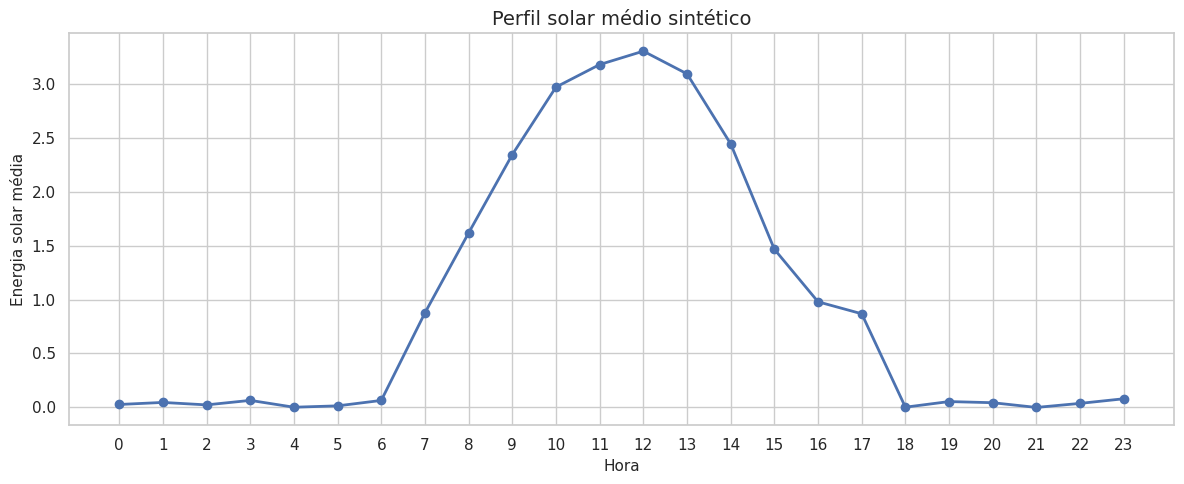

In [ ]:
# Visualização rápida da energia solar média sintética
solar_media = df_dados.groupby("hora", as_index=False)["energia_solar"].mean()

plt.figure()
plt.plot(solar_media["hora"], solar_media["energia_solar"], marker="o", linewidth=2)
plt.title("Perfil solar médio sintético")
plt.xlabel("Hora")
plt.ylabel("Energia solar média")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## 3. Formulação do ILP em PuLP

### Variáveis de decisão
- `x[i,t] ∈ {0,1}`: nó `i` ativo no tempo `t`
- `m[i,t] ∈ {0,1}`: migração proativa no tempo `t`
- `B[i,t] ≥ 0`: nível de bateria
- `E_marrom[i,t] ≥ 0`: energia marrom consumida

### Função objetivo
Minimizar:
- carbono associado ao uso de energia marrom
- custo/penalidade de migração

### Restrições principais
1. **K-Resiliência**: pelo menos `K` nós ativos a cada hora
2. **Cobertura do déficit com energia marrom**
3. **Atualização da bateria**
4. **Limite máximo da bateria**
5. **Migração quando há desligamento de um nó**

In [ ]:
# ---------------------------------------------------------
# Modelo ILP com PuLP
# ---------------------------------------------------------
modelo = pulp.LpProblem("Solar_Aware_Edge_Computing_ILP", pulp.LpMinimize)

# Variáveis
x = pulp.LpVariable.dicts("x", [(i, t) for i in nos for t in horas], cat="Binary")
m = pulp.LpVariable.dicts("m", [(i, t) for i in nos for t in horas], cat="Binary")
B = pulp.LpVariable.dicts(
    "B", [(i, t) for i in nos for t in horas],
    lowBound=0, upBound=B_max, cat="Continuous"
)
E_marrom = pulp.LpVariable.dicts(
    "E_marrom", [(i, t) for i in nos for t in horas],
    lowBound=0, cat="Continuous"
)

# Função objetivo (forma linear coerente com o texto do artigo)
modelo += pulp.lpSum(
    alpha * CFR[i] * E_marrom[(i, t)] + beta * custo_migracao[i] * m[(i, t)]
    for i in nos for t in horas
), "Minimizar_Carbono_e_Custo_de_Migracao"

# Restrição 1: K-Resiliência
for t in horas:
    modelo += pulp.lpSum(x[(i, t)] for i in nos) >= K, f"K_Resiliencia_hora_{t}"

# Restrições energéticas:
# - E_marrom cobre apenas o déficit instantâneo
# - a bateria é atualizada ao longo do tempo
# - migração ocorre quando um nó desliga de t-1 para t
for i in nos:
    # No instante inicial não forçamos migração
    modelo += m[(i, 0)] == 0, f"Sem_Migracao_Inicial_no_{i}"

    for t in horas:
        B_anterior = bateria_inicial[i] if t == 0 else B[(i, t - 1)]
        demanda = P_cons * x[(i, t)] + P_mig * m[(i, t)]

        # Energia marrom cobre apenas o déficit necessário
        modelo += (
            E_marrom[(i, t)] >= demanda - (energia_solar[(i, t)] + B_anterior)
        ), f"Deficit_Energetico_no_{i}_hora_{t}"

        # Não permitimos usar energia marrom acima da própria demanda do período
        modelo += (
            E_marrom[(i, t)] <= demanda
        ), f"Limite_Energia_Marrom_no_{i}_hora_{t}"

        # Atualização da bateria
        modelo += (
            B[(i, t)] == B_anterior + energia_solar[(i, t)] + E_marrom[(i, t)] - demanda
        ), f"Atualizacao_Bateria_no_{i}_hora_{t}"

        # Condição de migração quando há desligamento 1 -> 0
        if t >= 1:
            x_anterior = x[(i, t - 1)]
            modelo += (
                m[(i, t)] >= x_anterior - x[(i, t)]
            ), f"Aciona_Migracao_no_{i}_hora_{t}"
            modelo += (
                m[(i, t)] <= x_anterior
            ), f"Migracao_so_se_estava_ativo_no_{i}_hora_{t}"
            modelo += (
                m[(i, t)] <= 1 - x[(i, t)]
            ), f"Migracao_so_quando_desliga_no_{i}_hora_{t}"

# Exporta o modelo em formato LP
modelo.writeLP(str(PASTA_MODELO / "modelo_solar_aware.lp"))

print("Modelo construído com sucesso.")
print("Número de variáveis:", len(modelo.variables()))
print("Número de restrições:", len(modelo.constraints))

Modelo construído com sucesso.
Número de variáveis: 480
Número de restrições: 734


In [ ]:
# ---------------------------------------------------------
# Resolução com CBC
# ---------------------------------------------------------
# Observação: usamos o CBC (solver padrão do PuLP) com limite de tempo curto
# para manter a execução confortável no Colab. Com a semente adotada neste
# notebook, a solução obtida é ótima nesta instância sintética.
solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=8)
status = modelo.solve(solver)

status_texto = pulp.LpStatus[modelo.status]
valor_objetivo = float(pulp.value(modelo.objective))

print("Status do solver:", status_texto)
print("Valor da função objetivo:", round(valor_objetivo, 6))

with open(PASTA_MODELO / "status_solver.txt", "w", encoding="utf-8") as f:
    f.write(f"Status do solver: {status_texto}\n")
    f.write(f"Valor da função objetivo: {valor_objetivo}\n")

Status do solver: Optimal
Valor da função objetivo: 10.038141


## 4. Extração e salvamento da solução ótima

In [ ]:
# ---------------------------------------------------------
# Extração dos resultados
# ---------------------------------------------------------
linhas_resultado = []
for i in nos:
    for t in horas:
        linhas_resultado.append({
            "no": i,
            "hora": t,
            "ativo": int(round(pulp.value(x[(i, t)]))),
            "migracao": int(round(pulp.value(m[(i, t)]))),
            "bateria": round(float(pulp.value(B[(i, t)])), 6),
            "energia_marrom": round(float(pulp.value(E_marrom[(i, t)])), 6),
            "energia_solar": energia_solar[(i, t)],
            "CFR": CFR[i],
            "custo_migracao": custo_migracao[i]
        })

df_resultado = pd.DataFrame(linhas_resultado)
df_resultado.to_csv(PASTA_TABELAS / "solucao_detalhada.csv", index=False, encoding="utf-8")

# Resumo por hora
resumo_horario = (
    df_resultado
    .groupby("hora", as_index=False)
    .agg(
        nos_ativos=("ativo", "sum"),
        migracoes=("migracao", "sum"),
        energia_marrom_total=("energia_marrom", "sum"),
        bateria_media=("bateria", "mean"),
        energia_solar_media=("energia_solar", "mean")
    )
)

# Rótulo interpretativo simples de operação
resumo_horario["modo_operacao"] = np.where(
    resumo_horario["nos_ativos"] <= K,
    "Operação no limite de K-resiliência",
    "Operação com folga energética"
)

resumo_horario.to_csv(PASTA_TABELAS / "resumo_horario.csv", index=False, encoding="utf-8")

# Tabelas auxiliares
tabela_ativacao = df_resultado.pivot(index="no", columns="hora", values="ativo")
tabela_migracao = df_resultado.pivot(index="no", columns="hora", values="migracao")
tabela_bateria = df_resultado.pivot(index="no", columns="hora", values="bateria")
tabela_energia_marrom = df_resultado.pivot(index="no", columns="hora", values="energia_marrom")

tabela_ativacao.to_csv(PASTA_TABELAS / "matriz_ativacao.csv", encoding="utf-8")
tabela_migracao.to_csv(PASTA_TABELAS / "matriz_migracao.csv", encoding="utf-8")
tabela_bateria.to_csv(PASTA_TABELAS / "matriz_bateria.csv", encoding="utf-8")
tabela_energia_marrom.to_csv(PASTA_TABELAS / "matriz_energia_marrom.csv", encoding="utf-8")

display(resumo_horario.head(10))

,hora,nos_ativos,migracoes,energia_marrom_total,bateria_media,energia_solar_media,modo_operacao
0,0,2,0,3.600,5.9294,0.0274,Operação no limite de K-resiliência
1,1,2,0,0.000,5.2558,0.0464,Operação no limite de K-resiliência
2,2,2,0,1.800,4.9194,0.0236,Operação no limite de K-resiliência
3,3,2,0,1.667,4.5982,0.0654,Operação no limite de K-resiliência
4,4,2,0,0.000,3.8802,0.0020,Operação no limite de K-resiliência
5,5,3,0,1.800,3.1748,0.0146,Operação com folga energética
6,6,4,0,3.476,2.4950,0.0650,Operação com folga energética
7,7,4,0,1.416,2.2150,0.8768,Operação com folga energética
8,8,5,0,0.688,2.1702,1.6176,Operação com folga energética
9,9,5,0,0.000,2.7140,2.3438,Operação com folga energética


In [ ]:
# Métricas finais
metricas_finais = {
    "status_solver": status_texto,
    "valor_objetivo": valor_objetivo,
    "energia_marrom_total": float(resumo_horario["energia_marrom_total"].sum()),
    "migracoes_totais": int(resumo_horario["migracoes"].sum()),
    "minimo_nos_ativos": int(resumo_horario["nos_ativos"].min()),
    "cumpre_k_resiliencia": bool(resumo_horario["nos_ativos"].min() >= K),
    "hora_pico_migracao": int(resumo_horario.loc[resumo_horario["migracoes"].idxmax(), "hora"]),
    "hora_pico_energia_marrom": int(resumo_horario.loc[resumo_horario["energia_marrom_total"].idxmax(), "hora"])
}

with open(PASTA_RELATORIOS / "metricas_finais.json", "w", encoding="utf-8") as f:
    json.dump(metricas_finais, f, ensure_ascii=False, indent=2)

metricas_finais

{'status_solver': 'Optimal',
 'valor_objetivo': 10.038141000000001,
 'energia_marrom_total': 21.817,
 'migracoes_totais': 2,
 'minimo_nos_ativos': 2,
 'cumpre_k_resiliencia': True,
 'hora_pico_migracao': 17,
 'hora_pico_energia_marrom': 0}

## 5. Gráficos finais do experimento

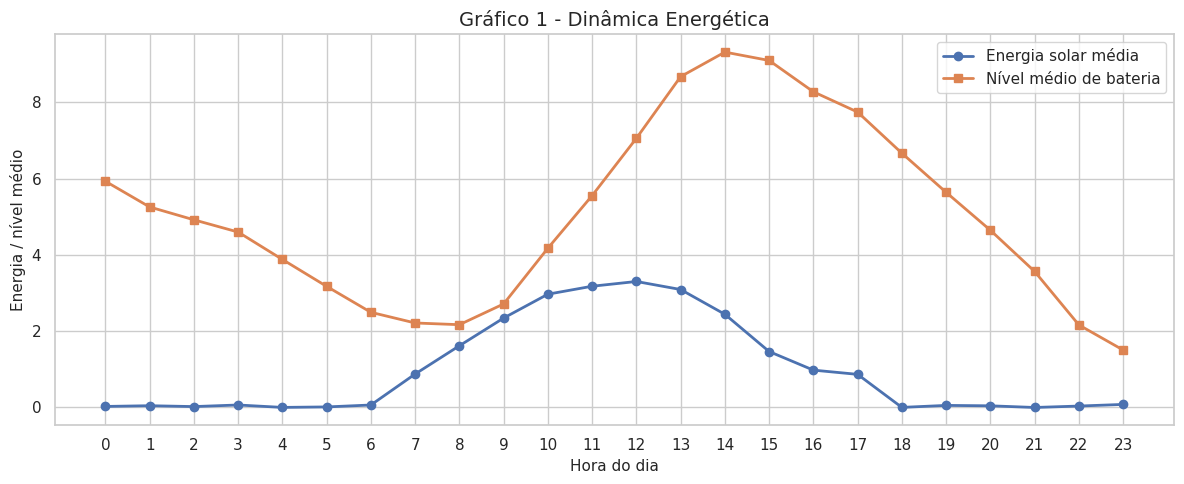

In [ ]:
# ---------------------------------------------------------
# Gráfico 1: Dinâmica Energética
# ---------------------------------------------------------
plt.figure()
plt.plot(
    resumo_horario["hora"], resumo_horario["energia_solar_media"],
    marker="o", linewidth=2, label="Energia solar média"
)
plt.plot(
    resumo_horario["hora"], resumo_horario["bateria_media"],
    marker="s", linewidth=2, label="Nível médio de bateria"
)
plt.title("Gráfico 1 - Dinâmica Energética")
plt.xlabel("Hora do dia")
plt.ylabel("Energia / nível médio")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "grafico_1_dinamica_energetica.png", dpi=300, bbox_inches="tight")
plt.show()

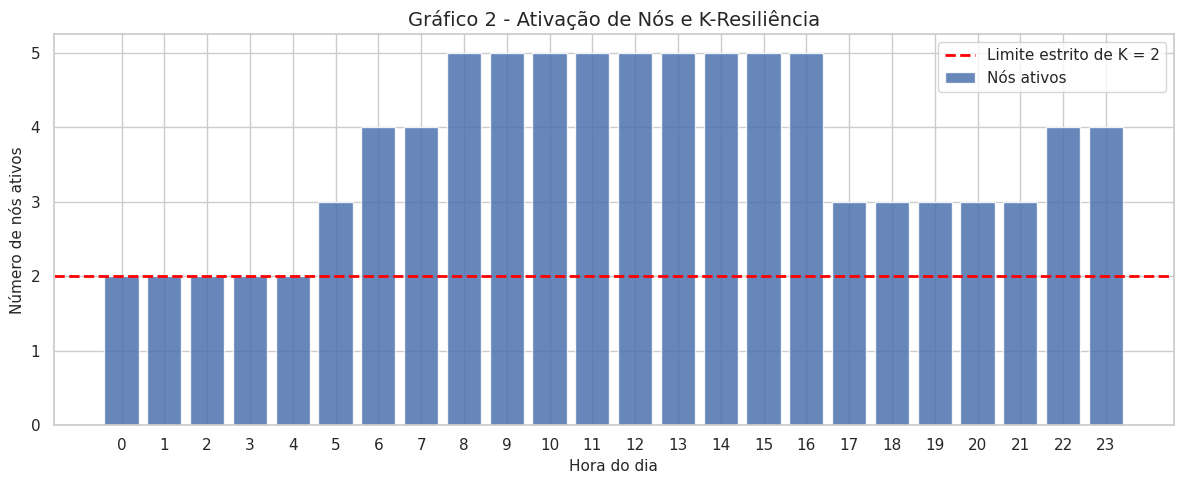

In [ ]:
# ---------------------------------------------------------
# Gráfico 2: Ativação e K-Resiliência
# ---------------------------------------------------------
plt.figure()
plt.bar(
    resumo_horario["hora"], resumo_horario["nos_ativos"],
    alpha=0.85, label="Nós ativos"
)
plt.axhline(
    y=K, color="red", linestyle="--", linewidth=2,
    label=f"Limite estrito de K = {K}"
)
plt.title("Gráfico 2 - Ativação de Nós e K-Resiliência")
plt.xlabel("Hora do dia")
plt.ylabel("Número de nós ativos")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "grafico_2_k_resiliencia.png", dpi=300, bbox_inches="tight")
plt.show()

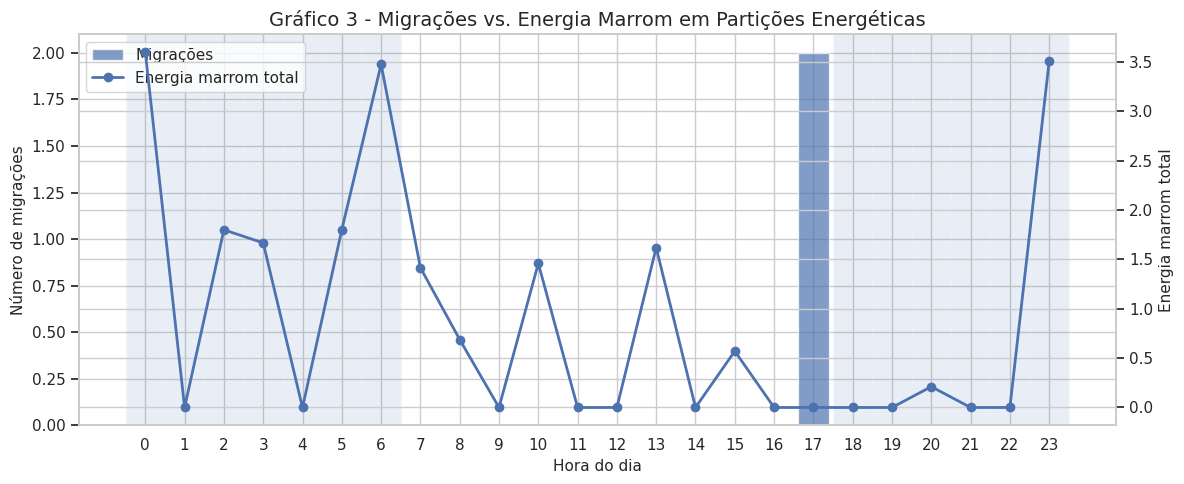

In [ ]:
# ---------------------------------------------------------
# Gráfico 3: Migrações e Energia Marrom
# ---------------------------------------------------------
limiar_particao_energetica = 0.15
resumo_horario["particao_energetica"] = (
    resumo_horario["energia_solar_media"] <= limiar_particao_energetica
).astype(int)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(
    resumo_horario["hora"], resumo_horario["migracoes"],
    alpha=0.7, label="Migrações"
)
ax1.set_xlabel("Hora do dia")
ax1.set_ylabel("Número de migrações")

ax2 = ax1.twinx()
ax2.plot(
    resumo_horario["hora"], resumo_horario["energia_marrom_total"],
    marker="o", linewidth=2, label="Energia marrom total"
)
ax2.set_ylabel("Energia marrom total")

for h in resumo_horario.loc[resumo_horario["particao_energetica"] == 1, "hora"]:
    ax1.axvspan(h - 0.5, h + 0.5, alpha=0.12)

linhas1, rotulos1 = ax1.get_legend_handles_labels()
linhas2, rotulos2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc="upper left")

plt.title("Gráfico 3 - Migrações vs. Energia Marrom em Partições Energéticas")
plt.xticks(range(24))
plt.tight_layout()
plt.savefig(PASTA_GRAFICOS / "grafico_3_migracoes_vs_energia_marrom.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ---------------------------------------------------------
# Relatório textual resumido
# ---------------------------------------------------------
texto_relatorio = f"""# Relatório Resumido do Experimento Solar-Aware

## Status da otimização
- Status do solver: {metricas_finais['status_solver']}
- Valor da função objetivo: {metricas_finais['valor_objetivo']:.6f}

## Indicadores principais
- Energia marrom total: {metricas_finais['energia_marrom_total']:.6f}
- Migrações totais: {metricas_finais['migracoes_totais']}
- Mínimo de nós ativos: {metricas_finais['minimo_nos_ativos']}
- Cumpre K-resiliência: {metricas_finais['cumpre_k_resiliencia']}

## Interpretação
O experimento busca uma linha de base offline do "Limite de Resiliência", balanceando:
1. uso de energia marrom (impacto de carbono),
2. custo de migração proativa,
3. manutenção da restrição de K-resiliência.

Nos períodos de baixa geração solar, o modelo decide entre:
- manter nós ativos com suporte energético,
- acionar migrações,
- preservar a disponibilidade mínima exigida.

## Arquivos gerados
- Tabelas CSV em: resultados/tabelas/
- Gráficos PNG em: resultados/graficos/
- Modelo LP e status em: resultados/modelo/
- Métricas e relatório em: resultados/relatorios/
"""

with open(PASTA_RELATORIOS / "relatorio_resumido.md", "w", encoding="utf-8") as f:
    f.write(texto_relatorio)

print(texto_relatorio)

# Relatório Resumido do Experimento Solar-Aware

## Status da otimização
- Status do solver: Optimal
- Valor da função objetivo: 10.038141

## Indicadores principais
- Energia marrom total: 21.817000
- Migrações totais: 2
- Mínimo de nós ativos: 2
- Cumpre K-resiliência: True

## Interpretação
O experimento busca uma linha de base offline do "Limite de Resiliência", balanceando:
1. uso de energia marrom (impacto de carbono),
2. custo de migração proativa,
3. manutenção da restrição de K-resiliência.

Nos períodos de baixa geração solar, o modelo decide entre:
- manter nós ativos com suporte energético,
- acionar migrações,
- preservar a disponibilidade mínima exigida.

## Arquivos gerados
- Tabelas CSV em: resultados/tabelas/
- Gráficos PNG em: resultados/graficos/
- Modelo LP e status em: resultados/modelo/
- Métricas e relatório em: resultados/relatorios/



## 6. Empacotamento para download

Esta célula gera um `.zip` com todos os arquivos produzidos pelo experimento.
Se estiver rodando no Google Colab, ela também tenta iniciar o download automaticamente.

In [ ]:
# ---------------------------------------------------------
# Gera ZIP final para download
# ---------------------------------------------------------
caminho_zip = PASTA_EXPORT / "pacote_resultados_solar_aware.zip"

if caminho_zip.exists():
    caminho_zip.unlink()

with zipfile.ZipFile(caminho_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for arquivo in PASTA_BASE.rglob("*"):
        if arquivo.is_file() and arquivo != caminho_zip:
            zf.write(arquivo, arcname=arquivo.relative_to(PASTA_BASE.parent))

print("Arquivo ZIP gerado em:")
print(caminho_zip.resolve())

# Tentativa de download automático no Colab
try:
    from google.colab import files
    files.download(str(caminho_zip))
except Exception as e:
    print("Download automático não iniciado (normal fora do Colab).")
    print("Mensagem:", e)

Arquivo ZIP gerado em:
/content/experimento_solar_aware/exportacao/pacote_resultados_solar_aware.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Inspeção rápida dos arquivos gerados
arquivos_gerados = []
for arquivo in sorted(PASTA_BASE.rglob("*")):
    if arquivo.is_file():
        arquivos_gerados.append({
            "arquivo": str(arquivo),
            "tamanho_bytes": arquivo.stat().st_size
        })

df_arquivos = pd.DataFrame(arquivos_gerados)
display(df_arquivos.head(50))
print(f"Total de arquivos gerados: {len(df_arquivos)}")

,arquivo,tamanho_bytes
0,experimento_solar_aware/dados/dados_sinteticos...,3122
1,experimento_solar_aware/dados/dados_sinteticos...,16984
2,experimento_solar_aware/dados/parametros_exper...,427
3,experimento_solar_aware/exportacao/pacote_resu...,554662
4,experimento_solar_aware/resultados/graficos/gr...,209376
5,experimento_solar_aware/resultados/graficos/gr...,122813
6,experimento_solar_aware/resultados/graficos/gr...,297263
7,experimento_solar_aware/resultados/modelo/mode...,71432
8,experimento_solar_aware/resultados/modelo/stat...,73
9,experimento_solar_aware/resultados/relatorios/...,250


Total de arquivos gerados: 17
